# 09 — Confounder Analysis

**Scientific question:** Are blood-based gene expression biomarkers truly predictive
of tissue pathology, or is the signal driven by donor demographics (age, sex, race, etc.)
that correlate with disease?

Three models per tissue × category:
- **Conf-only** — RF with demographics alone (SEX, AGE, RACE, DTHHRDY, TRISCHD)
- **Expr-only** — RF with expression alone (baseline, from notebook 07)
- **Expr+Conf** — RF with expression + demographics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from gtex_biomarkers.config import Config
from gtex_biomarkers.data import (
    load_cache, variance_filter,
    build_confounder_matrix,
)
from gtex_biomarkers.labels import discover_tissue_category_pairs
from gtex_biomarkers.models import make_rf_model
from gtex_biomarkers.utils import run_all_confounder_models_parallel

Config.ensure_dirs()

X_wb, blood_subjid, _, df_meta_url, df_age = load_cache()

Loaded cache from /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/data/cache/processed_data.pkl
  X_wb: 803 samples × 59033 genes


## 9.1 — Build Confounder Matrix

Map donor-level demographics (SEX, AGE, RACE, DTHHRDY, TRISCHD) to each blood sample.
RACE codes 98/99 (unknown) are treated as NaN and median-imputed.

In [2]:
X_conf = build_confounder_matrix(df_age, blood_subjid)
print(f"Confounder matrix: {X_conf.shape[0]} samples × {X_conf.shape[1]} features")
print(f"Features: {list(X_conf.columns)}")
print()
display(X_conf.describe().round(2))
display(X_conf.head(10))

Confounder matrix: 803 samples × 5 features
Features: ['SEX', 'AGE', 'RACE', 'DTHHRDY', 'TRISCHD']



,SEX,AGE,RACE,DTHHRDY,TRISCHD
count,803.00,803.00,803.00,803.00,803.00
mean,1.33,52.81,2.85,1.12,491.91
std,0.47,13.03,0.40,1.40,410.54
min,1.00,20.00,1.00,0.00,0.00
25%,1.00,47.00,3.00,0.00,79.00
50%,1.00,55.00,3.00,0.00,447.00
75%,2.00,63.00,3.00,2.00,824.50
max,2.00,70.00,4.00,4.00,1641.00


,SEX,AGE,RACE,DTHHRDY,TRISCHD
GTEX-1117F-0005-SM-HL9SH,2,66,2.0,4.0,1200.0
GTEX-111CU-0005-SM-GJ3PH,1,57,3.0,0.0,43.0
GTEX-111FC-0006-SM-H65Z1,1,61,3.0,1.0,1028.0
GTEX-111YS-0006-SM-5NQBE,1,62,3.0,0.0,74.0
GTEX-1122O-0005-SM-5O99J,2,64,3.0,0.0,35.0
GTEX-1128S-0005-SM-5P9HI,2,66,3.0,2.0,816.0
GTEX-113IC-0006-SM-5NQ9C,1,66,2.0,0.0,94.0
GTEX-113JC-0006-SM-5O997,2,53,3.0,2.0,611.0
GTEX-117XS-0005-SM-5PNU6,1,64,3.0,2.0,848.0
GTEX-117YW-0005-SM-5NQ8Z,1,58,3.0,3.0,785.0


## 9.2 — Discover Tissue × Category Pairs

In [3]:
pairs_df = discover_tissue_category_pairs(df_meta_url)
print(f"Total tissue × category pairs (≥ {Config.ALL_TISSUE_THRESHOLD} samples): {len(pairs_df)}")
display(pairs_df)

Total tissue × category pairs (≥ 50 samples): 53


,tissue,category,n_samples
0,Adipose - Subcutaneous,fibrosis,137
1,Adipose - Visceral (Omentum),fibrosis,99
2,Artery - Aorta,atherosis,221
3,Artery - Aorta,atherosclerosis,101
4,Artery - Aorta,sclerotic,64
5,Artery - Aorta,calcification,53
6,Artery - Coronary,calcification,158
7,Artery - Coronary,atherosclerosis,153
8,Artery - Coronary,sclerotic,124
9,Artery - Coronary,atherosis,116


## 9.3 — Run Models (Parallelized by Tissue)

For each tissue × category pair, train two RF models:
- **Model A**: Confounders only (SEX, AGE, RACE, DTHHRDY, TRISCHD)
- **Model B**: Variance-filtered expression (top 100 per fold) + all confounders

In [4]:
# Variance-filtered expression (top 20K genes) — same as notebook 07
X_wb_var, _ = variance_filter(X_wb)
print(f"Variance-filtered expression: {X_wb_var.shape[0]} samples × {X_wb_var.shape[1]} genes")

conf_results, conf_summary, comb_results, comb_summary = \
    run_all_confounder_models_parallel(
        pairs_df, df_meta_url, blood_subjid,
        X_wb_var, X_conf, make_rf_model
    )

print(f"Completed {len(conf_results)} confounder-only models")
print(f"Completed {len(comb_results)} expression+confounder models")

Variance-filtered expression: 803 samples × 20000 genes


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done   6 out of  19 | elapsed:  8.4min remaining: 18.3min
[Parallel(n_jobs=-1)]: Done   8 out of  19 | elapsed:  8.5min remaining: 11.7min
[Parallel(n_jobs=-1)]: Done  10 out of  19 | elapsed: 10.0min remaining:  9.0min
[Parallel(n_jobs=-1)]: Done  12 out of  19 | elapsed: 10.8min remaining:  6.3min
[Parallel(n_jobs=-1)]: Done  14 out of  19 | elapsed: 10.8min remaining:  3.8min
[Parallel(n_jobs=-1)]: Done  16 out of  19 | elapsed: 12.2min remaining:  2.3min


Completed 53 confounder-only models
Completed 53 expression+confounder models


[Parallel(n_jobs=-1)]: Done  19 out of  19 | elapsed: 16.2min finished


## 9.4 — Three-Way Comparison

Merge confounder-only (Model A), expression-only (notebook 07 baseline), and expression+confounder (Model C).

**Delta = AUC(Expr+Conf) − AUC(Conf-only)** — how much does expression add beyond demographics?

In [5]:
# Save model summaries
conf_summary.to_csv(Config.TABLES_DIR / "cv_results_confounder_only.csv", index=False)
comb_summary.to_csv(Config.TABLES_DIR / "cv_results_expr_plus_confounder.csv", index=False)

# Load expression-only RF results (baseline from notebook 07)
expr_only_path = Config.TABLES_DIR / "cv_results_all_tissue_rf.csv"
if not expr_only_path.exists():
    raise FileNotFoundError("Run notebook 07 first to generate expression-only RF results.")
expr_summary = pd.read_csv(expr_only_path)

# Three-way merge
three_way = (
    conf_summary[["tissue", "category", "mean_auc"]]
    .rename(columns={"mean_auc": "auc_conf"})
    .merge(
        expr_summary[["tissue", "category", "mean_auc"]]
        .rename(columns={"mean_auc": "auc_expr"}),
        on=["tissue", "category"], how="inner",
    )
    .merge(
        comb_summary[["tissue", "category", "mean_auc"]]
        .rename(columns={"mean_auc": "auc_comb"}),
        on=["tissue", "category"], how="inner",
    )
)

# Delta: how much does expression add beyond confounders alone?
three_way["delta"] = three_way["auc_comb"] - three_way["auc_conf"]
three_way = three_way.sort_values("auc_expr", ascending=False)
three_way.to_csv(Config.TABLES_DIR / "cv_three_way_comparison.csv", index=False)

print(f"Total models: {len(three_way)}")
print(f"Mean delta (Expr+Conf − Conf-only): {three_way['delta'].mean():.4f}")
print(f"Median delta: {three_way['delta'].median():.4f}")
display(three_way)

Total models: 53
Mean delta (Expr+Conf − Conf-only): 0.0452
Median delta: 0.0351


,tissue,category,auc_conf,auc_expr,auc_comb,delta
0,Breast - Mammary Tissue,gynecomastoid,0.868507,0.881665,0.875403,0.006897
1,Breast - Mammary Tissue,atrophy,0.772285,0.841520,0.844138,0.071853
3,Spleen,congestion,0.720674,0.826177,0.816906,0.096232
21,Liver,cirrhosis,0.566866,0.804298,0.794705,0.227839
2,Breast - Mammary Tissue,hyperplasia,0.754917,0.752899,0.751471,-0.003446
6,Lung,pneumonia,0.640349,0.736086,0.741729,0.101380
4,Pancreas,saponification,0.717051,0.730258,0.731118,0.014067
5,Testis,spermatogenesis,0.650235,0.711798,0.719460,0.069225
9,Muscle - Skeletal,atrophy,0.618750,0.693750,0.691667,0.072917
12,Liver,congestion,0.593976,0.683426,0.683816,0.089840


## 9.5 — Figure: Dumbbell Plot of ΔAUC

Each row is one tissue × category pair. The two endpoints show:
- **Conf-only AUC** (orange) — demographics alone
- **Expr+Conf AUC** (purple) — expression + demographics

The connecting line length is the **ΔAUC**. Rows are grouped by tissue, sorted by delta within each tissue.

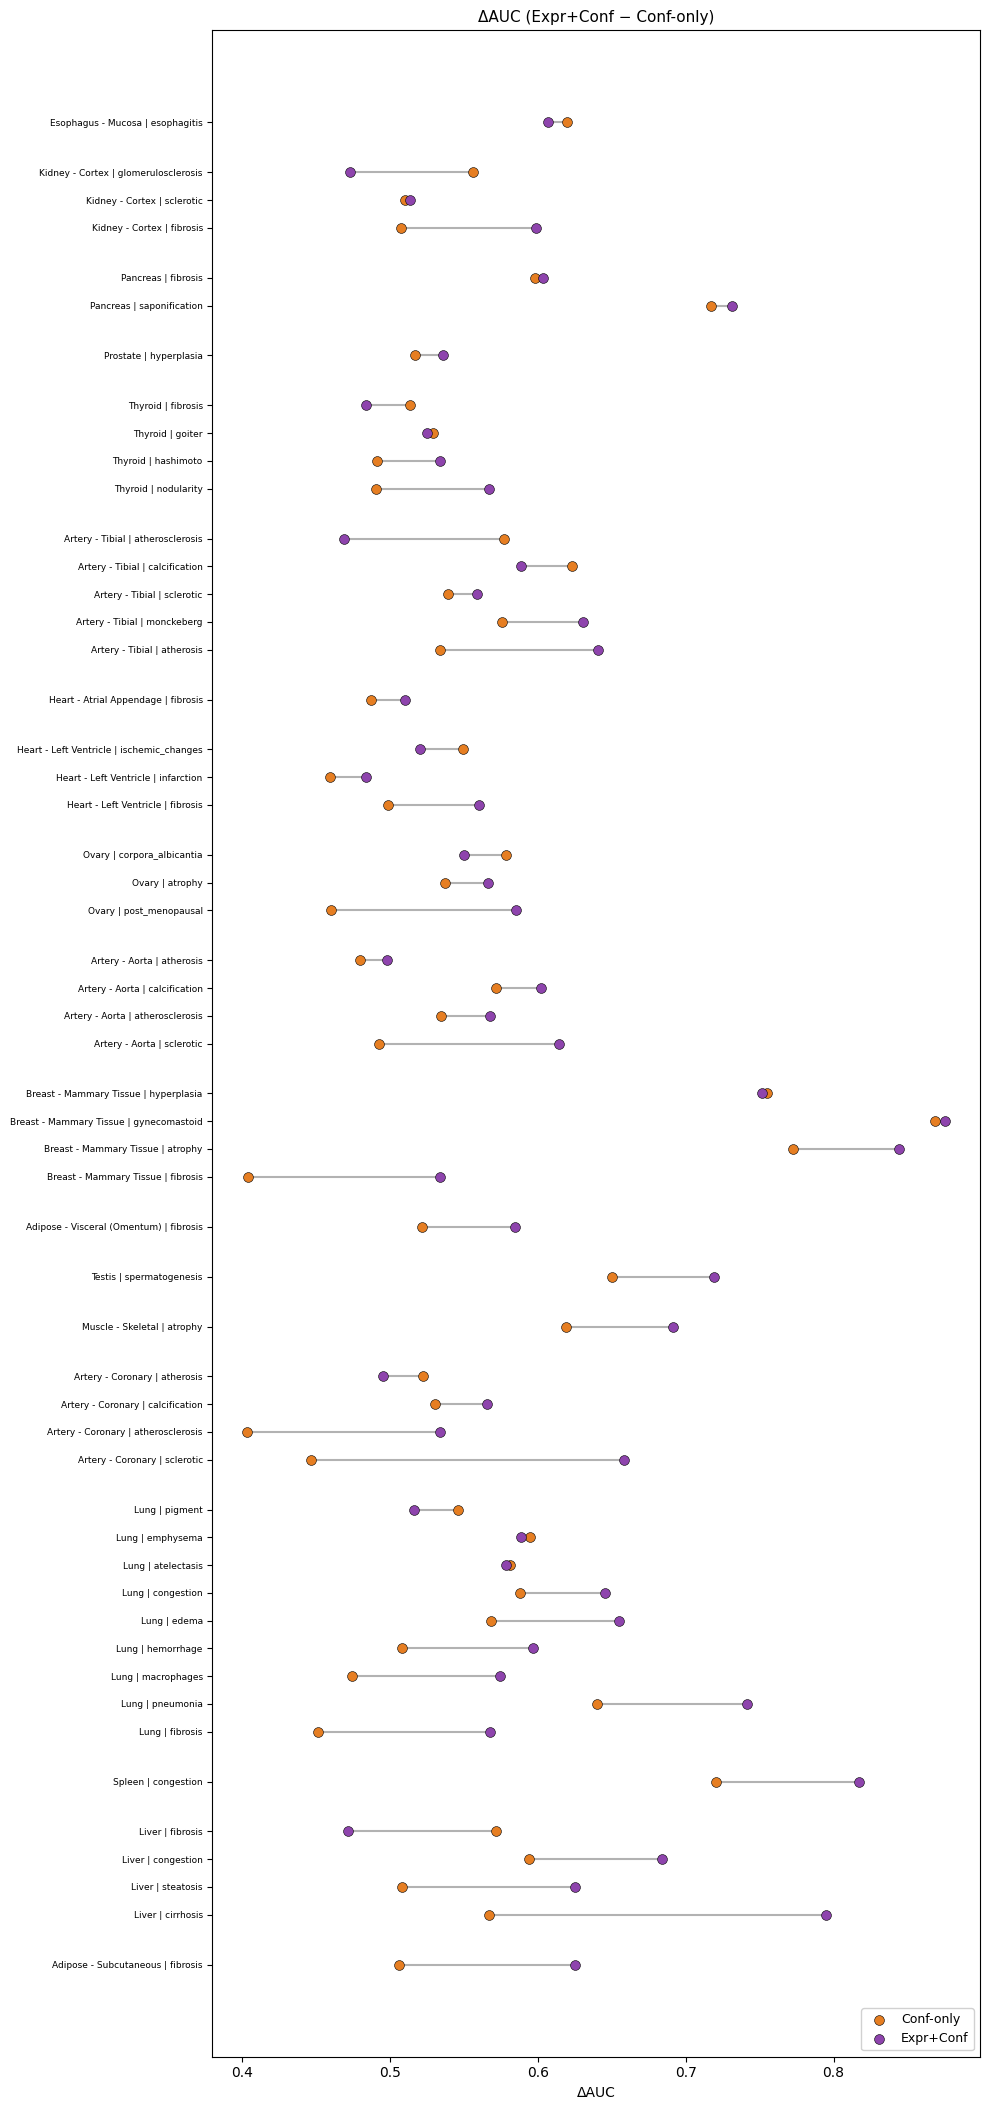

In [6]:
# Figure: Dumbbell plot — Conf-only vs Expr+Conf for each tissue×category
tw = three_way.copy()
tw["label"] = tw["tissue"] + " | " + tw["category"]

# Sort: group by tissue (ordered by median delta), within tissue by delta
tissue_median = tw.groupby("tissue")["delta"].median().sort_values(ascending=True)
tissue_order = tissue_median.index.tolist()
tw["tissue_rank"] = tw["tissue"].map({t: i for i, t in enumerate(tissue_order)})
tw = tw.sort_values(["tissue_rank", "delta"], ascending=[True, True]).reset_index(drop=True)

# Build y-positions with gaps between tissue groups
y_pos = []
y = 0
prev_tissue = None
for _, row in tw.iterrows():
    if prev_tissue is not None and row["tissue"] != prev_tissue:
        y += 0.8  # gap between tissue groups
    y_pos.append(y)
    y += 1
    prev_tissue = row["tissue"]
tw["y"] = y_pos

fig, ax = plt.subplots(figsize=(10, max(8, len(tw) * 0.4)))

# Connecting lines
for _, row in tw.iterrows():
    ax.plot([row["auc_conf"], row["auc_comb"]], [row["y"], row["y"]],
            color="grey", lw=1.5, alpha=0.6, zorder=1)

# Conf-only dots (orange)
ax.scatter(tw["auc_conf"], tw["y"], color="#e67e22", s=50, zorder=3,
           edgecolors="black", lw=0.4, label="Conf-only")

# Expr+Conf dots (purple)
ax.scatter(tw["auc_comb"], tw["y"], color="#8e44ad", s=50, zorder=3,
           edgecolors="black", lw=0.4, label="Expr+Conf")

# Y-axis: tissue | category labels
ax.set_yticks(tw["y"].values)
ax.set_yticklabels(tw["label"].values, fontsize=6.5)
ax.set_xlabel("ΔAUC", fontsize=10)
ax.set_title("ΔAUC (Expr+Conf − Conf-only)", fontsize=11)
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / "delta_auc_dumbbell.pdf", bbox_inches="tight")
plt.show()